## Apple Inc. (AAPL)  Exploratory Data Analysis

### Overview
This notebook presents an exploratory data analysis (EDA) of financial news headlines related to **Apple Inc. (AAPL)**. The analysis is part of a broader project at **Nova Financial Solutions** aimed at building a predictive analytics pipeline that connects market narratives to stock price movements.

### Objectives
- Understand the structure and statistical properties of the financial news dataset
- Identify common keywords, themes, and topics in AAPL-related headlines
- Analyze publication trends and volume spikes over time
- Examine publisher activity and contribution patterns

### Dataset
The analysis uses the **Financial News and Stock Price Integration Dataset (FNSPID)**, which contains financial news headlines, publication dates, publisher information, and associated stock ticker symbols.

## 1. Import Libraries

In [13]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

from src.data_loader import load_news_data, filter_by_stock
from src.text_analyzer import (
    clean_headline,
    get_tfidf_keywords,
    get_word_frequency,
    get_lda_topics,
    extract_email_domains
)
from src.visualizer import (
    plot_headline_length,
    plot_publisher_activity,
    plot_email_domains,
    plot_time_series,
    plot_keywords,
    plot_lda_topics
)

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("✅ All libraries imported successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


✅ All libraries imported successfully!


## 2. Loading the Data

We load the raw financial news dataset using our modular `load_news_data()` function from `src/data_loader.py`. This keeps our notebook clean and ensures consistent data loading across all notebooks.

In [14]:
df = load_news_data('../data/raw/raw_analyst_ratings.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

✅ Loaded 1407328 news articles.
Dataset Shape: (1407328, 5)

Column Names: ['headline', 'url', 'publisher', 'date', 'stock']

First 5 rows:


,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A


## 3. Data Filtering

We filter the dataset for **AAPL** articles only using our modular `filter_by_stock()` function. The cleaning was already handled inside `load_news_data()`.

In [15]:
aapl_df = filter_by_stock(df, 'AAPL')

print(f"\nDate range: {aapl_df['date'].min().date()} to {aapl_df['date'].max().date()}")
print(f"\nMissing values:\n{aapl_df.isnull().sum()}")
aapl_df.head()

✅ Found 441 articles for AAPL.

Date range: 2020-03-09 to 2020-06-10

Missing values:
headline     0
url          0
publisher    0
date         0
stock        0
dtype: int64


,headline,url,publisher,date,stock
0,Tech Stocks And FAANGS Strong Again To Start D...,https://www.benzinga.com/government/20/06/1622...,JJ Kinahan,2020-06-10 15:33:26+00:00,AAPL
1,10 Biggest Price Target Changes For Wednesday,https://www.benzinga.com/analyst-ratings/price...,Lisa Levin,2020-06-10 12:14:08+00:00,AAPL
2,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",https://www.benzinga.com/short-sellers/20/06/1...,Benzinga Newsdesk,2020-06-10 11:53:47+00:00,AAPL
3,"Deutsche Bank Maintains Buy on Apple, Raises P...",https://www.benzinga.com/news/20/06/16219873/d...,Benzinga Newsdesk,2020-06-10 11:19:25+00:00,AAPL
4,Apple To Let Users Trade In Their Mac Computer...,https://www.benzinga.com/news/20/06/16218697/a...,Neer Varshney,2020-06-10 10:27:11+00:00,AAPL


## 4. Descriptive Statistics

In this section we examine the basic statistical properties of the dataset including headline length distribution, article count over time, and a general summary of the data.

In [16]:
aapl_df['headline_length'] = aapl_df['headline'].apply(len)

print("=== Headline Length Statistics ===")
print(aapl_df['headline_length'].describe())

print(f"\n=== Sample Headlines ===")
for h in aapl_df['headline'].sample(5, random_state=42).values:
    print(f"• {h}")

=== Headline Length Statistics ===
count    441.000000
mean      86.997732
std       48.087019
min       21.000000
25%       61.000000
50%       74.000000
75%       92.000000
max      373.000000
Name: headline_length, dtype: float64

=== Sample Headlines ===
• Retail Pro Says Giants Like Amazon, Walmart Will Prevail After Coronavirus: 'It's Not Fair'
• Investor Movement Index Summary: February 2020
• Apple CEO Tim Cook Sees Remote Work Sector Accelerating
• 10 Biggest Price Target Changes For Wednesday
• Starbucks Switches To 'To Go' Model As Coronavirus Spreads, Closes Some Stores


### 4.1 Headline Length Distribution

We visualize the distribution of headline character lengths to understand how concise or verbose the financial news headlines tend to be.

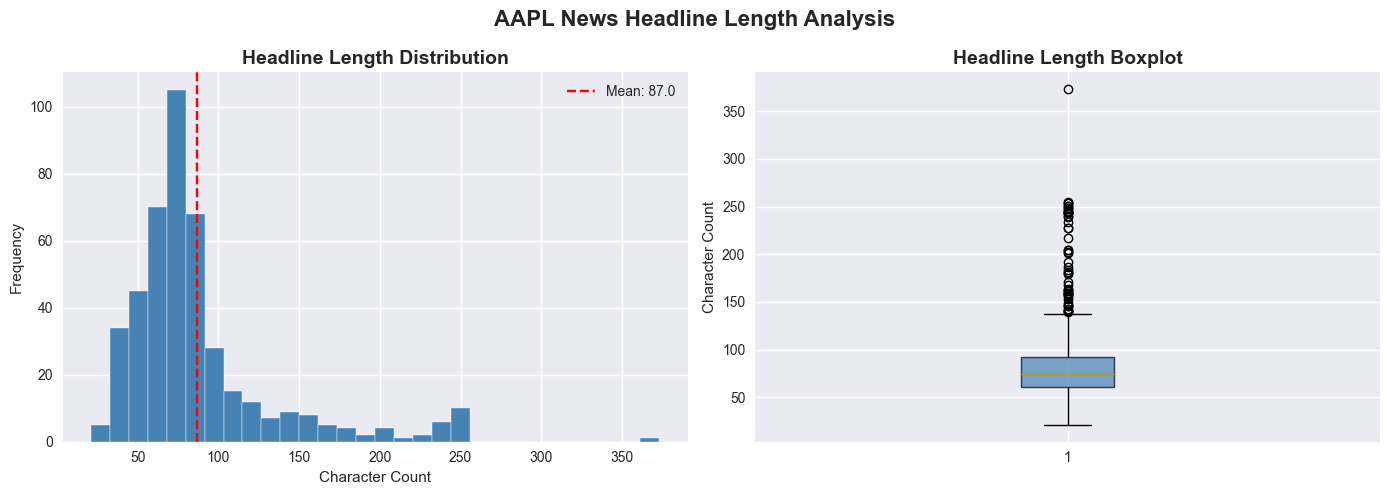

In [17]:
plot_headline_length(aapl_df, 'AAPL')

## 5. Publisher Analysis

We identify the most active publishers contributing to AAPL-related news. Understanding which sources dominate the coverage helps assess potential bias and the diversity of market perspectives.

In [18]:
publisher_counts = aapl_df['publisher'].value_counts()

print(f"Total unique publishers: {publisher_counts.nunique()}")
print(f"\nTop 10 most active publishers:")
print(publisher_counts.head(10))

Total unique publishers: 15

Top 10 most active publishers:
publisher
Benzinga Newsdesk    139
Neer Varshney         47
JJ Kinahan            37
Lisa Levin            32
Charles Gross         25
IAM Newswire          25
Shivdeep Dhaliwal     20
Vick Meyer            20
Shanthi Rexaline      13
Tanzeel Akhtar         9
Name: count, dtype: int64


### 5.1 Publisher Activity Visualization

The bar chart below highlights the dominance of certain publishers in AAPL news coverage, particularly **Benzinga Newsdesk** which accounts for the majority of articles.

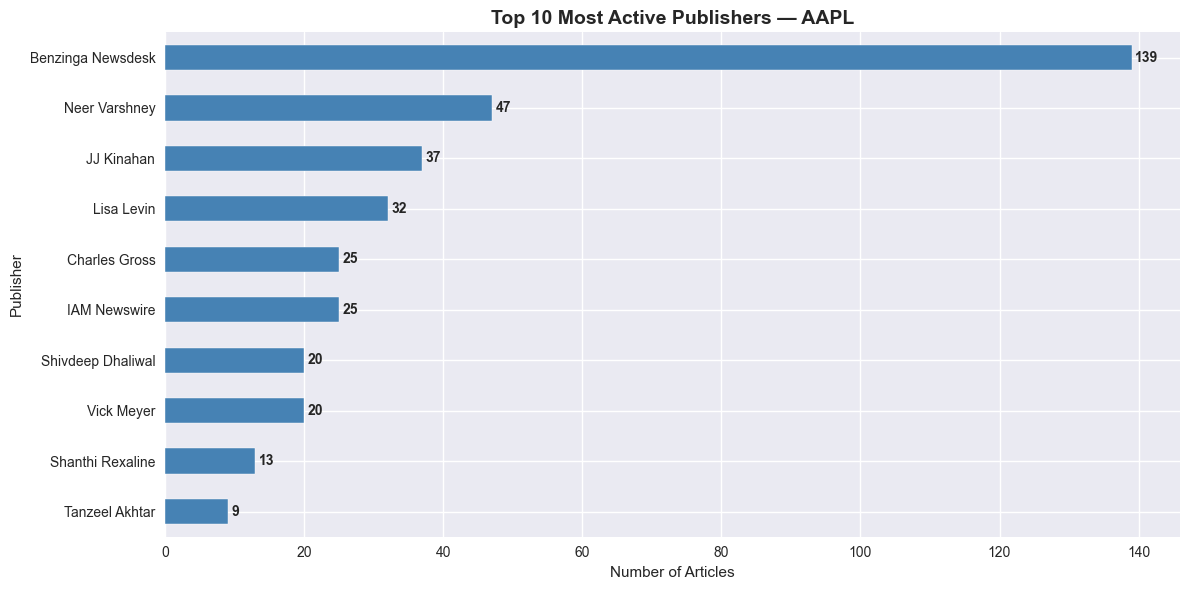

In [19]:
plot_publisher_activity(publisher_counts, 'AAPL')

### 5.2 Email Publisher Domain Analysis

Some publishers use email addresses as their names. We extract the domain from these emails to identify the organizations contributing to the news coverage.

Articles from email-based publishers: 4
Unique email publishers: 1

Top domains:
         domain  count
0  benzinga.com      4


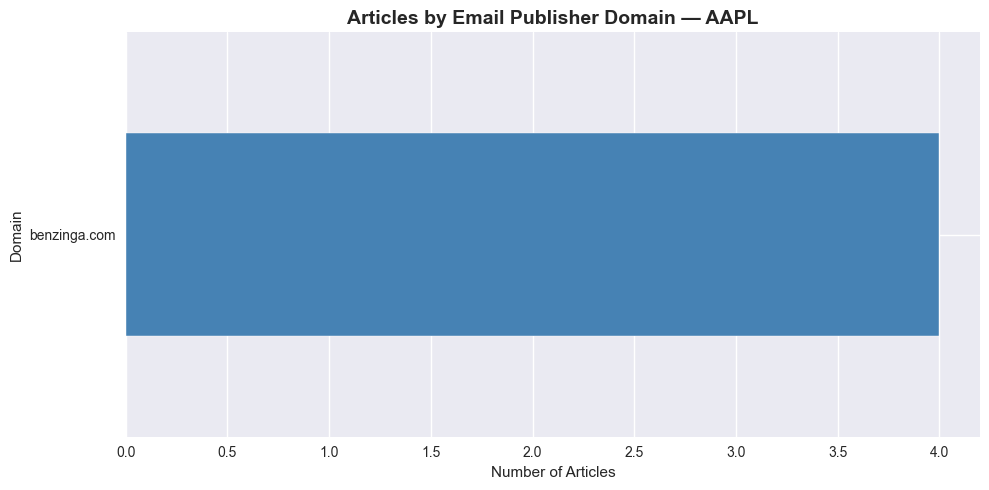

In [20]:
email_pubs = aapl_df[aapl_df['publisher'].str.contains('@', na=False)]
print(f"Articles from email-based publishers: {len(email_pubs)}")
print(f"Unique email publishers: {email_pubs['publisher'].nunique()}")

domain_counts = extract_email_domains(aapl_df)
print(f"\nTop domains:\n{domain_counts}")

plot_email_domains(domain_counts, 'AAPL')

## 6. Time Series Analysis of News Volume

We analyze how AAPL-related article publication frequency varies over time. Spikes in news volume often correlate with significant market events such as earnings releases, product launches, or macroeconomic developments.

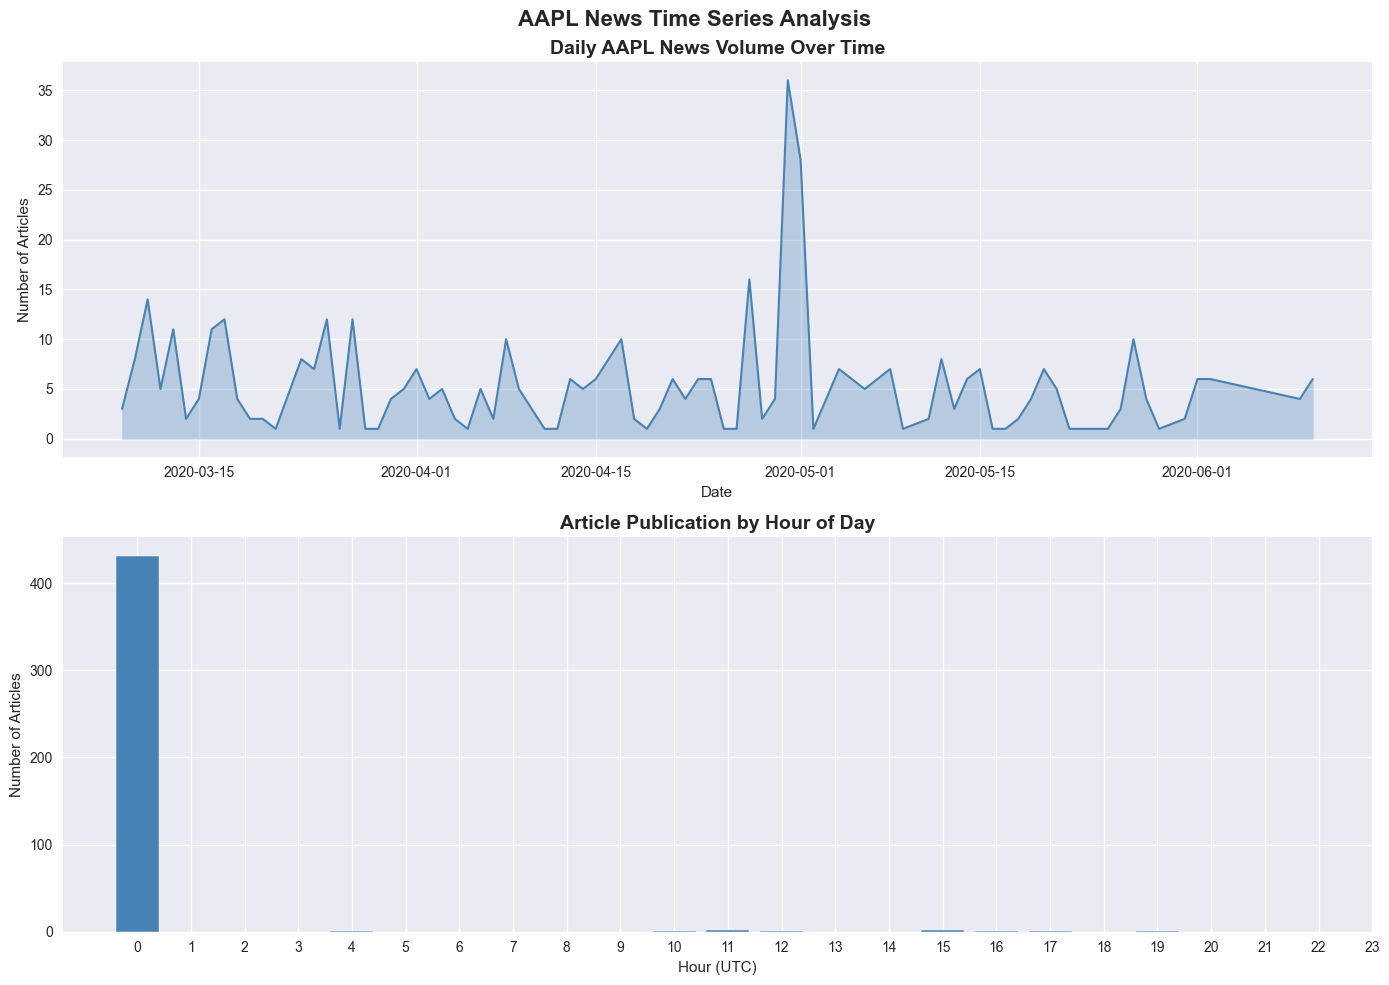

In [21]:
aapl_df['date_only'] = aapl_df['date'].dt.date
aapl_df['hour'] = aapl_df['date'].dt.hour
aapl_df['day_of_week'] = aapl_df['date'].dt.day_name()

daily_counts = aapl_df.groupby('date_only').size()

plot_time_series(aapl_df, daily_counts, 'AAPL')

## 7. Text Analysis & Topic Modeling

We apply NLP techniques to extract the most frequent keywords and themes from AAPL-related headlines using three complementary approaches: **TF-IDF**, **CountVectorizer**, and **LDA Topic Modeling**.

In [22]:
aapl_df['cleaned_headline'] = aapl_df['headline'].apply(clean_headline)

tfidf_matrix, tfidf_keywords, tfidf_scores = get_tfidf_keywords(
    aapl_df['cleaned_headline'])
word_freq = get_word_frequency(aapl_df['cleaned_headline'])

print("Top 20 Keywords (TF-IDF):")
print(tfidf_keywords)
print(f"\nTop 20 Keywords (Frequency):")
print(word_freq)

Top 20 Keywords (TF-IDF):
['amid' 'apple' 'buy' 'china' 'companies' 'coronavirus' 'earnings'
 'higher' 'iphone' 'lowers' 'maintains' 'market' 'price' 'price target'
 'says' 'shares' 'stocks' 'stores' 'target' 'trading']

Top 20 Keywords (Frequency):
         keyword  frequency
1          apple        243
18        target         51
12         price         47
14          says         46
15        shares         46
13  price target         45
5    coronavirus         40
8         iphone         36
16        stocks         32
6       earnings         31
19       trading         30
10     maintains         27
11        market         26
2            buy         25
17        stores         23
3          china         21
7         higher         21
0           amid         20
9         lowers         20
4      companies         20


### 7.1 Top Keywords Visualization

The most frequently occurring keywords reveal the dominant themes in AAPL news coverage. Notable themes include **COVID-19 impact**, **price target changes**, **iPhone sales**, and **China operations** — all highly relevant during the March–June 2020 period.

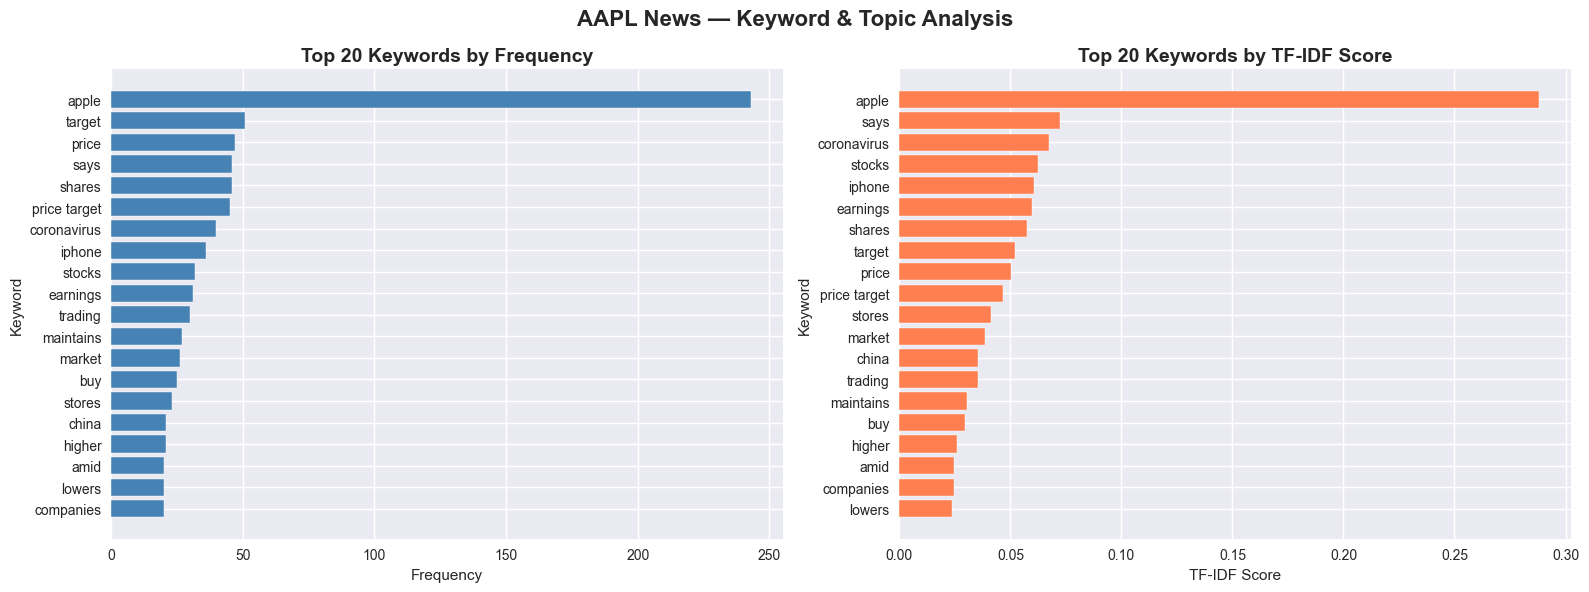

In [23]:
plot_keywords(word_freq, tfidf_keywords, tfidf_scores, 'AAPL')

### 7.2 LDA Topic Modeling

Latent Dirichlet Allocation (LDA) is an unsupervised machine learning technique that discovers hidden topics in a collection of documents. We use LDA to identify the main themes discussed in AAPL-related headlines.

=== LDA Topic Modeling Results ===
Number of topics: 5

Topic 1: apple, stocks, ceo, tim, cook, earnings, session, iphone, moving, china
Topic 2: apple, report, new, shares, global, biggest, coronavirus, year, update, covid
Topic 3: apple, says, coronavirus, apples, week, amazon, earnings, microsoft, services, tech
Topic 4: apple, target, price, maintains, buy, lowers, raises, iphone, morgan, overweight
Topic 5: apple, shares, trading, higher, says, market, amid, companies, coronavirus, technology


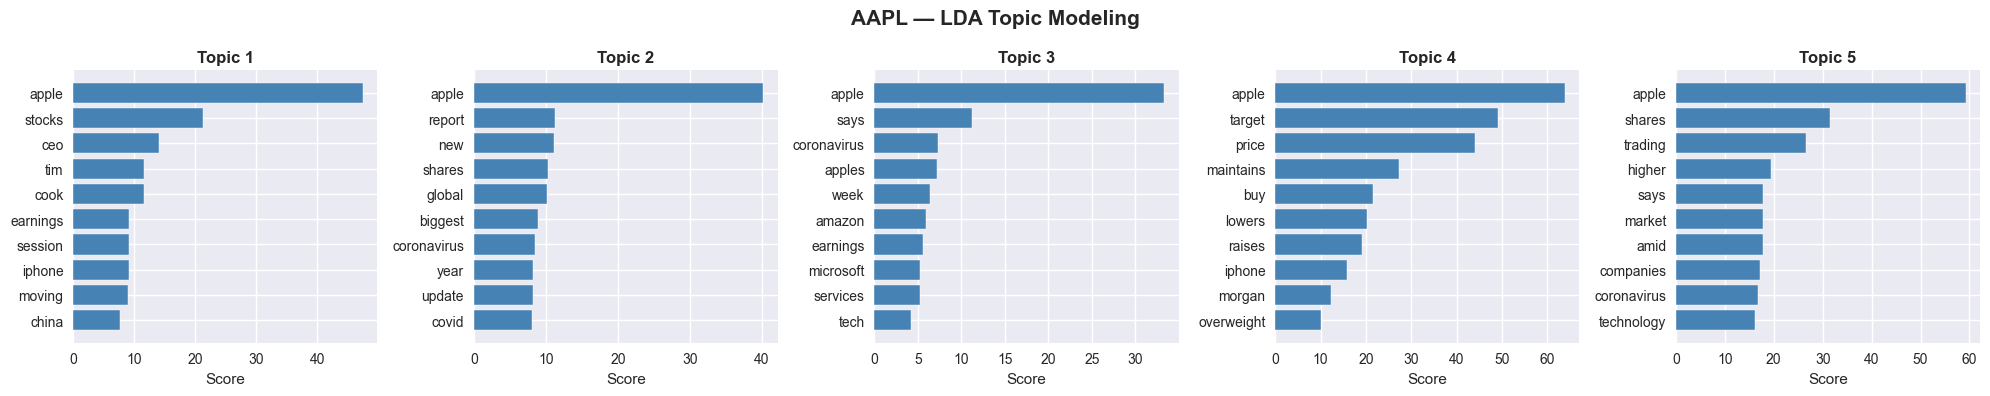

In [24]:
lda_model, feature_names, topics = get_lda_topics(
    aapl_df['cleaned_headline'], n_topics=5)

print("=== LDA Topic Modeling Results ===")
print(f"Number of topics: 5\n")
for i, topic in enumerate(topics):
    print(f"Topic {i+1}: {', '.join(topic)}")

plot_lda_topics(lda_model, feature_names, 5, 'AAPL')

## 8. Key Findings & Summary

A summary of the most important insights derived from the exploratory data analysis of AAPL-related financial news headlines.

In [25]:
print("=" * 55)
print("        AAPL EDA — KEY FINDINGS SUMMARY")
print("=" * 55)

print(f"""
📰 DATASET OVERVIEW
- Total AAPL articles analyzed : {len(aapl_df)}
- Date range                   : {aapl_df['date'].min().date()} to {aapl_df['date'].max().date()}
- Unique publishers            : {aapl_df['publisher'].nunique()}

📏 HEADLINE STATISTICS
- Average headline length      : {aapl_df['headline_length'].mean():.1f} characters
- Shortest headline            : {aapl_df['headline_length'].min()} characters
- Longest headline             : {aapl_df['headline_length'].max()} characters

📰 PUBLISHER INSIGHTS
- Most active publisher        : {aapl_df['publisher'].value_counts().index[0]}
- Articles by top publisher    : {aapl_df['publisher'].value_counts().iloc[0]}

📈 NEWS VOLUME INSIGHTS
- Highest single day volume    : {daily_counts.max()} articles
- Date of highest volume       : {daily_counts.idxmax()}

🔑 TOP THEMES IDENTIFIED
- Price targets & analyst ratings
- COVID-19 / Coronavirus impact
- iPhone sales & product updates
- China operations & supply chain
- Stock trading & market movement
""")
print("=" * 55)

        AAPL EDA — KEY FINDINGS SUMMARY

📰 DATASET OVERVIEW
- Total AAPL articles analyzed : 441
- Date range                   : 2020-03-09 to 2020-06-10
- Unique publishers            : 33

📏 HEADLINE STATISTICS
- Average headline length      : 87.0 characters
- Shortest headline            : 21 characters
- Longest headline             : 373 characters

📰 PUBLISHER INSIGHTS
- Most active publisher        : Benzinga Newsdesk
- Articles by top publisher    : 139

📈 NEWS VOLUME INSIGHTS
- Highest single day volume    : 36 articles
- Date of highest volume       : 2020-04-30

🔑 TOP THEMES IDENTIFIED
- Price targets & analyst ratings
- COVID-19 / Coronavirus impact
- iPhone sales & product updates
- China operations & supply chain
- Stock trading & market movement



## 9. Conclusion

The EDA of AAPL financial news reveals a dataset heavily influenced by the **COVID-19 pandemic period (March–June 2020)**. Key themes include analyst price target revisions, iPhone demand concerns, and Apple's China supply chain disruptions.

**Benzinga Newsdesk** dominates coverage, accounting for the majority of articles. Most articles lack a specific publication time, suggesting batch publishing practices. Email-based publishers are predominantly from **benzinga.com**, confirming the platform's dominance in financial news coverage.

LDA topic modeling revealed 5 distinct themes in the AAPL coverage, providing deeper insight beyond simple keyword frequency analysis.

These insights will inform the sentiment analysis and correlation study in the subsequent notebook.